# 2. Comprensión de los datos

## 2.1 Descripción de los datos

Como previamente mencionamos, contamos con un conjunto de datos de consultas de pacientes con 1010 registros y 27 variables que fueron recopiladas durante su tratamiento, como podemos ver en la muestra a continuación:

In [1]:
import pandas as pd
from IPython.display import HTML

df = pd.read_csv('dataset_salud_nayarit.csv', encoding="utf-8-sig")

styled_df = df.head(3).style.hide(axis='index').set_properties(**{
    'text-align': 'left',
    'white-space': 'normal',
    'word-wrap': 'break-word',
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white'), ('padding', '8px'), ('white-space', 'normal')]},
    {'selector': 'td', 'props': [('padding', '6px')]},
    {'selector': 'table', 'props': [('width', '100%'), ('border-collapse', 'collapse')]}
])

display(HTML(f'''
<div style="overflow-x: auto; width: calc(100% - 128px); margin-left: 64px;">
    {styled_df.to_html()}
</div>
'''))

id_paciente,fecha_consulta,municipio,tipo_unidad,tipo_seguro,edad,genero,peso_kg,talla_cm,imc,presion_sistolica,presion_diastolica,glucosa_mg_dl,colesterol_mg_dl,trigliceridos_mg_dl,hemoglobina_g_dl,diabetes_previa,hipertension_previa,cardiopatia_previa,fumador,consumo_alcohol,actividad_fisica,num_medicamentos_actuales,num_consultas_ano_prev,escolaridad,ocupacion,hospitalizacion
NAY-00630,09-18-2024,Tepic,Clínica IMSS,Seguro Popular / Bienestar,36.000000,F,76.600000,172.000000,25.900000,125,81.000000,64.000000,160,nan,14.000000,Sí,No,No,No,si,Sedentario,1.000000,7,Primaria incompleta,Ama de casa,0
NAY-00789,17/09/2024,Tepic,Hospital General,Seguro Popular / Bienestar,52.000000,M,74.200000,165.000000,27.300000,158,92.000000,121.000000,143,170,13.400000,No,si,No,No,No,Moderado,2.000000,7,Primaria completa,Agricultor/a,0
NAY-00685,23/10/2023,Ruiz,Clínica IMSS,Sin seguro,19.000000,Hombre,64.900000,181.000000,19.800000,130,74.000000,117.000000,199,123,nan,No,NEGATIVO,No,Sí,NEGATIVO,Sedentario,2.000000,11,Preparatoria / Bachillerato,Jornalero/a,0


En base a estas muestras, generamos el siguiente diccionario de datos:

In [2]:
meta = {
    'id_paciente': ('Identificador', 'Clave única'),
    'fecha_consulta': ('Fecha', 'Fecha de la consulta'),
    'municipio': ('Categórico', 'Municipio de Nayarit'),
    'tipo_unidad': ('Categórico', 'Tipo de unidad médica'),
    'tipo_seguro': ('Categórico', 'Tipo de seguro del paciente'),
    'edad': ('Numérico', 'Edad en años'),
    'genero': ('Categórico', 'Sexo biológico'),
    'peso_kg': ('Numérico', 'Peso en kilogramos'),
    'talla_cm': ('Numérico', 'Estatura en centímetros'),
    'imc': ('Numérico', 'Índice de Masa Corporal'),
    'presion_sistolica': ('Numérico', 'Presión sistólica (mmHg)'),
    'presion_diastolica': ('Numérico', 'Presión diastólica (mmHg)'),
    'glucosa_mg_dl': ('Numérico', 'Glucosa en sangre'),
    'colesterol_mg_dl': ('Numérico', 'Colesterol total'),
    'trigliceridos_mg_dl': ('Numérico', 'Triglicéridos'),
    'hemoglobina_g_dl': ('Numérico', 'Hemoglobina (g/dL)'),
    'diabetes_previa': ('Booleano', 'Diagnóstico previo de diabetes'),
    'hipertension_previa': ('Booleano', 'Diagnóstico previo de hipertensión'),
    'cardiopatia_previa': ('Booleano', 'Diagnóstico previo de cardiopatía'),
    'fumador': ('Booleano', 'Condición de fumador actual del paciente'),
    'consumo_alcohol': ('Booleano', 'Condición de consumo de alcohol recurrente por parte del paciente'),
    'actividad_fisica': ('Categórico', 'Indicador de la frecuencia en la realización de actividad física'),
    'num_medicamentos_actuales': ('Numérico', 'Número de fármacos en uso actual'),
    'num_consultas_ano_prev': ('Numérico', 'Consultas en el año anterior'),
    'escolaridad': ('Categórico', 'Último nivel de estudios'),
    'ocupacion': ('Categórico', 'Ocupación principal'),
    'hospitalizacion': ('Booleano', 'Indicador del paciente que señala si requirió ingreso hospitalario')
}

datos = []
for col in df.columns:
    tipo, desc = meta.get(col)
    serie_no_nula = df[col].dropna()
    if not serie_no_nula.empty:
        ejemplo = serie_no_nula.iloc[0]
        if isinstance(ejemplo, str) and len(ejemplo) > 80:
            ejemplo = ejemplo[:77] + '...'
    else:
        ejemplo = ''
    datos.append({
        'Variable': f"⭐ {col}" if col == 'hospitalizacion' else col,
        'Tipo': tipo,
        'Descripción': desc,
        'Ejemplo (de la muestra)': ejemplo
    })

df_dict = pd.DataFrame(datos)

styled_df = df_dict.style.hide(axis='index').set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white'), ('padding', '8px'), ('white-space', 'normal'), ('text-align', 'left')]},
    {'selector': 'td', 'props': [('padding', '6px'), ('text-align', 'left'), ('white-space', 'normal'), ('word-wrap', 'break-word')]},
    {'selector': '', 'props': [('width', '100%')]}
])

display(HTML('<div style="overflow-x: auto; width: calc(100% - 128px); margin-left: 64px;">' + styled_df.to_html() + '</div>'))

Variable,Tipo,Descripción,Ejemplo (de la muestra)
id_paciente,Identificador,Clave única,NAY-00630
fecha_consulta,Fecha,Fecha de la consulta,09-18-2024
municipio,Categórico,Municipio de Nayarit,Tepic
tipo_unidad,Categórico,Tipo de unidad médica,Clínica IMSS
tipo_seguro,Categórico,Tipo de seguro del paciente,Seguro Popular / Bienestar
edad,Numérico,Edad en años,36.000000
genero,Categórico,Sexo biológico,F
peso_kg,Numérico,Peso en kilogramos,76.600000
talla_cm,Numérico,Estatura en centímetros,172.000000
imc,Numérico,Índice de Masa Corporal,25.900000


Como se observa en el diccionario de datos, identificamos formalmente la existencia de nuestra **variable objetivo** (marcada con una ⭐), denominada `hospitalizacion`. A partir de la caracterización de sus valores, constatamos que es de tipo **categórico binaria** , ya que únicamente clasifica los registros entre pacientes que requirieron ingreso hospitalario o aquellos cuya consulta fue puramente ambulatoria.

## 2.2 Establecimiento de volumen de la información

El objetivo de esta sección dentro de la metodología es encontrar los problemas de calidad de datos que serán atendidos dentro de la fase de limpieza de datos. Para lograr esto, primero, haremos uso de un Análisis Exploratorio, para posteriormente documentar los problemas de calidad de los datos. Asimismo, incluimos una breve recapitulación de cada acción de limpieza para cada problema de calidad de datos, con su correspondiente justificación.  Lo previamente mencionado se lleva a cabo a continuación:

### *Análisis Exploratorio de Datos (EDA)*

Antes de documentar formalmente los problemas de calidad, realizamos un análisis exploratorio rápido del dataset. Este análisis nos permite comprender la estructura general, identificar valores atípicos, nulos, duplicados y posibles incoherencias en los tipos de datos. Las funciones nativas de `pandas` nos dan una primera radiografía que orientará las reglas de limpieza posteriores.

#### Realizamos un Identificamos el tamaño de nuestro dataset

In [3]:
display(HTML(f'<div style="margin-left: auto; margin-right: auto; max-width: 80vw; text-align: center; font-family: Roboto, sans-serif;"><strong>Dimensiones del dataset:</strong><br><span style="background-color: #4CAF50; color: white; padding: 5px 10px; border-radius: 5px; display: inline-block; margin-top: 5px;">Filas: {df.shape[0]} | Columnas: {df.shape[1]}</span></div>'))

#### Analizamos el tipo de dato y cantidad de nulos de las columnas

In [4]:
columnas_numericas = [col for col, (tipo, _) in meta.items() if tipo == 'Numérico' and col in df.columns]

null_info = pd.DataFrame({
    'Columna': df.columns,
    'Tipo Actual': df.dtypes.astype(str),
    'No Nulos': df.count().values,
    'Nulos': df.isnull().sum().values,
    '% Nulos': (df.isnull().sum() / len(df) * 100).round(2).values
})

def get_expected_type(col):
    if col not in meta:
        return 'Categórico'
    tipo = meta[col][0]
    if tipo == 'Identificador':
        return 'Identificador'
    return tipo

def get_actual_category(dtype):
    if dtype.kind in 'iuf':
        return 'Numérico'
    elif dtype == bool:
        return 'Booleano'
    elif dtype == 'datetime64[ns]':
        return 'Fecha'
    else:
        return 'Categórico'

null_info['Tipo Esperado'] = null_info['Columna'].apply(get_expected_type)
null_info['Categoría Actual'] = df.dtypes.apply(get_actual_category)

def highlight_cells(row):
    styles = [''] * len(row)
    if row['Nulos'] > 0:
        styles[null_info.columns.get_loc('Nulos')] = 'background-color: #d32f2f; color: white; font-weight: bold;'
        styles[null_info.columns.get_loc('% Nulos')] = 'background-color: #d32f2f; color: white; font-weight: bold;'
    expected = row['Tipo Esperado']
    actual = row['Categoría Actual']
    if expected == 'Identificador':
        expected = 'Categórico'
    if actual != expected:
        styles[null_info.columns.get_loc('Tipo Actual')] = 'background-color: #ff9800; color: white; font-weight: bold;'
    return styles

styled_null = null_info.style.hide(axis='index').apply(highlight_cells, axis=1)
styled_null = styled_null.hide(['Categoría Actual'], axis='columns')
styled_null = styled_null.set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white'), ('padding', '8px'), ('text-align', 'left')]},
    {'selector': 'td', 'props': [('padding', '6px'), ('text-align', 'left')]}
])

display(HTML('<div style="display: flex; justify-content: center; width: 100%;">' + styled_null.to_html() + '</div>'))

Columna,Tipo Actual,No Nulos,Nulos,% Nulos,Tipo Esperado
id_paciente,object,1010,0,0.000000,Identificador
fecha_consulta,object,1010,0,0.000000,Fecha
municipio,object,1010,0,0.000000,Categórico
tipo_unidad,object,1010,0,0.000000,Categórico
tipo_seguro,object,980,30,2.970000,Categórico
edad,float64,1010,0,0.000000,Numérico
genero,object,1010,0,0.000000,Categórico
peso_kg,float64,941,69,6.830000,Numérico
talla_cm,float64,960,50,4.950000,Numérico
imc,float64,893,117,11.580000,Numérico


##### A partir de esta tabla, realizamos las siguientes observaciones

- Los campos `fecha_consulta`, `presion_sistolica`, `colesterol_mg_dl`, `trigliceridos_mg_dl`, `diabetes_previa`, `hipertension_previa`, `cardiopatia_previa`, `fumador`, `consumo_alcohol`, `hospitalizacion` están marcados en un tipo de dato inconsistente al registrado en el diccionario de datos.
- Los campos `tipo_seguro`, `peso_kg`, `talla_cm`, `imc`, `presion_diastolica`, `colesterol_mg_dl`, `trigliceridos_mg_dl`, `hemoglobina_g_dl`, `num_medicamentos_actuales`, `escolaridad`, `ocupacion` contienen registros nulos.


##### Y ahora identificamos los valores inconsistentes con el tipo de dato de las columnas

In [5]:
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display, HTML
import pandas as pd
import numpy as np

inconsistencias = []

for col in df.columns:
    tipo_esperado = get_expected_type(col)
    serie = df[col]
    
    if tipo_esperado == 'Numérico':
        converted = pd.to_numeric(serie, errors='coerce')
        mask = serie.notna() & converted.isna()
        if mask.any():
            valores = serie[mask].unique()
            inconsistencias.append({
                'Columna': col,
                'Tipo Esperado': 'Numérico',
                'Valores inconsistentes': ', '.join(str(v) for v in valores[:5]),
                'Cantidad': mask.sum()
            })
    
    elif tipo_esperado == 'Booleano':
        validos = {'0', '1', 0, 1}
        mask = ~serie.isin(validos) & serie.notna()
        if mask.any():
            valores = serie[mask].unique()
            inconsistencias.append({
                'Columna': col,
                'Tipo Esperado': 'Booleano (0/1)',
                'Valores inconsistentes': ', '.join(str(v) for v in valores[:5]),
                'Cantidad': mask.sum()
            })
    
    elif tipo_esperado == 'Fecha':
        converted = pd.to_datetime(serie, errors='coerce', dayfirst=True)
        mask = serie.notna() & converted.isna()
        if mask.any():
            valores = serie[mask].unique()
            inconsistencias.append({
                'Columna': col,
                'Tipo Esperado': 'Fecha',
                'Valores inconsistentes': ', '.join(str(v) for v in valores[:5]),
                'Cantidad': mask.sum()
            })

if inconsistencias:
    df_inc = pd.DataFrame(inconsistencias)
    styled_inc = df_inc.style.hide(axis='index').set_properties(**{'text-align': 'left', 'white-space': 'normal'}).set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white'), ('padding', '8px'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('padding', '6px'), ('text-align', 'left')]}
    ])
    display(HTML('<div style="display: flex; justify-content: center; width: 100%;">' + styled_inc.to_html() + '</div>'))
else:
    display(HTML('<div style="text-align: center; font-family: Roboto, sans-serif;">No se encontraron valores inconsistentes con los tipos esperados.</div>'))

Columna,Tipo Esperado,Valores inconsistentes,Cantidad
fecha_consulta,Fecha,"17/09/2024, 23/10/2023, 14/04/2024, 22-03-2023, 09/03/2023",920
presion_sistolica,Numérico,"150/97, 143/78, 134/75, 156/88, 145/91",92
colesterol_mg_dl,Numérico,"?, Sin dato, --, SIN DATO, no aplica",18
trigliceridos_mg_dl,Numérico,"?, ND, no aplica, --, SIN DATO",9
diabetes_previa,Booleano (0/1),"Sí, No, NO, no, POSITIVO",991
hipertension_previa,Booleano (0/1),"No, si, NEGATIVO, Sí, True",988
cardiopatia_previa,Booleano (0/1),"No, Sí, NEGATIVO, False, no",989
fumador,Booleano (0/1),"No, Sí, no, NEGATIVO, True",980
consumo_alcohol,Booleano (0/1),"si, No, NEGATIVO, Sí, NO",989
hospitalizacion,Booleano (0/1),"No, Sí, NO, INGRESADO, False",50


- La columna `fecha_consulta` presenta 920 valores no reconocibles como fechas (formatos mixtos como dd/mm/aaaa, dd-mm-aaaa, etc.), lo que impide su conversión directa a datetime.
- La columna `presion_sistolica` contiene 92 valores no numéricos, incluyendo pares como "150/97", que probablemente registran presión sistólica/diastólica juntas en un solo campo.
- Las columnas `colesterol_mg_dl` y `trigliceridos_mg_dl` tienen valores no numéricos (por ejemplo, "?", "--", "SIN DATO", "no aplica") que deben ser tratados como nulos.
- Las variables booleanas (`diabetes_previa`, `hipertension_previa`, `cardiopatia_previa`, `fumador`, `consumo_alcohol` y la variable objetivo `hospitalizacion`) presentan múltiples representaciones no estándar (Sí/No, POSITIVO/NEGATIVO, True/False, etc.), lo que requiere estandarización a 0/1.


#### Contamos los registros duplicados en los datos

In [6]:
dups = df.duplicated().sum()
if dups > 0:
    display(HTML(f'<div style="margin-left: auto; margin-right: auto; max-width: 80vw; text-align: center; font-family: Roboto, sans-serif; background-color: #fff3cd; color: #856404; padding: 10px; border-radius: 5px; border-left: 5px solid #ffc107;"><strong>⚠️ Registros duplicados detectados:</strong> {dups} filas completamente duplicadas.</div>'))
else:
    display(HTML(f'<div style="margin-left: auto; margin-right: auto; max-width: 80vw; text-align: center; font-family: Roboto, sans-serif; background-color: #d4edda; color: #155724; padding: 10px; border-radius: 5px; border-left: 5px solid #28a745;"><strong>✅ Sin registros duplicados:</strong> No se encontraron filas completamente duplicadas.</div>'))

#### Generamos datos estadísticos sobre la distribución de los datos

In [7]:
display(HTML('<div style="margin-left: auto; margin-right: auto; max-width: 80vw; text-align: center; font-family: Roboto, sans-serif; margin-bottom: 10px;"><strong>📊 Estadísticos descriptivos (columnas numéricas):</strong></div>'))

desc = df.describe()

rangos_plausibles = {
    'edad': (0, 120),
    'peso_kg': (0.3, 635),
    'talla_cm': (25, 272),
    'imc': (10, 100),
    'presion_sistolica': (60, 260),
    'presion_diastolica': (30, 150),
    'glucosa_mg_dl': (20, 1000),
    'colesterol_mg_dl': (50, 500),
    'trigliceridos_mg_dl': (20, 2000),
    'hemoglobina_g_dl': (3, 25),
    'num_medicamentos_actuales': (0, 30),
    'num_consultas_ano_prev': (0, 100)
}

def highlight_outliers(df):
    styles = pd.DataFrame('', index=df.index, columns=df.columns)
    for col in df.columns:
        if col in rangos_plausibles:
            lower, upper = rangos_plausibles[col]
            for row in ['min', 'max']:
                if row in df.index:
                    val = df.loc[row, col]
                    if not pd.isna(val) and (val < lower or val > upper):
                        styles.loc[row, col] = 'background-color: #d32f2f; color: white; font-weight: bold;'
    return styles

styled_desc = desc.style.apply(highlight_outliers, axis=None).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white'), ('padding', '8px'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('padding', '6px'), ('text-align', 'center')]},
    {'selector': 'caption', 'props': [('caption-side', 'bottom'), ('font-size', '0.9em'), ('color', '#666'), ('margin-top', '5px')]}
])

display(HTML('<div style="display: flex; justify-content: center; width: 100%; overflow-x: auto;"><div style="min-width: 100%;">' + styled_desc.to_html() + '</div></div>'))

,edad,peso_kg,talla_cm,imc,presion_diastolica,glucosa_mg_dl,hemoglobina_g_dl,num_medicamentos_actuales,num_consultas_ano_prev
count,1010.000000,941.000000,960.000000,893.000000,918.000000,1010.000000,918.000000,960.000000,1010.000000
mean,49.506931,71.284060,158.010417,26.636954,83.835512,101.600495,13.711438,2.022917,5.652475
std,39.698098,31.105708,31.464140,7.039963,9.605646,37.929354,1.796722,1.819686,3.437538
min,-5.000000,5.000000,1.440000,13.100000,57.000000,3.200000,8.200000,0.000000,0.000000
25%,26.000000,60.000000,156.000000,22.200000,77.000000,83.000000,12.500000,1.000000,3.000000
50%,49.000000,69.500000,163.000000,25.800000,84.000000,99.000000,13.700000,2.000000,6.000000
75%,71.000000,78.300000,171.000000,30.200000,90.000000,119.000000,14.900000,3.000000,9.000000
max,999.000000,500.000000,195.000000,64.900000,113.000000,242.000000,19.000000,6.000000,11.000000


##### En este formato, podemos observar los siguientes valores atípicos

- Edad mínima de -5 años y máxima de 999 años
- Talla de 1.44 cm
- Glucosa en sangre de 3.2mg/dL ([Un nivel por debajo de 54 mg/dL (3.0 mmol/L) requiere de acción inmediata.](https://medlineplus.gov/spanish/ency/patientinstructions/000085.htm#:~:text=Un%20nivel%20de%20az%C3%BAcar%20en%20la%20sangre%20por%20debajo%20de%2054%20mg/dL%20\(3.0%20mmol/L\)%20requiere%20de%20acci%C3%B3n%20inmediata.))


#### Analizamos los distintos valores encontrados dentro de cada una de las variables categóricas

In [8]:
from IPython.display import display, HTML

categorical_cols = [col for col, (tipo, _) in meta.items() if tipo in ['Categórico', 'Booleano']]
categorical_cols = [col for col in categorical_cols if col not in ['id_paciente', 'fecha_consulta']]

color_palette = ['#e6194b', '#3cb44b', '#008080', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#e6beff', '#9a6324', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080', '#c49e6d', '#e377c2']

bad_values = {
    'escolaridad': ['--', 'ND', '?', 'SIN DATO', 'Sin dato', '999'],
    'diabetes_previa': ['POSITIVO', 'NEGATIVO', 'SI', 'NO', 'si', 'no', 'True', 'False', 'Sí', 'No'],
    'hipertension_previa': ['POSITIVO', 'NEGATIVO', 'SI', 'NO', 'si', 'no', 'True', 'False', 'Sí', 'No'],
    'cardiopatia_previa': ['POSITIVO', 'NEGATIVO', 'SI', 'NO', 'si', 'no', 'True', 'False', 'Sí', 'No'],
    'fumador': ['POSITIVO', 'NEGATIVO', 'SI', 'NO', 'si', 'no', 'True', 'False', 'Sí', 'No'],
    'consumo_alcohol': ['POSITIVO', 'NEGATIVO', 'SI', 'NO', 'si', 'no', 'True', 'False', 'Sí', 'No'],
    'hospitalizacion': ['No', 'Sí', 'NO', 'INGRESADO', 'AMBULATORIO', 'True', 'False', 'SI']
}

col_data = []
for col in categorical_cols:
    unique_vals = df[col].dropna().unique()
    if col == 'municipio':
        normalized = {}
        for v in unique_vals:
            norm = str(v).strip()
            if norm not in normalized:
                normalized[norm] = []
            normalized[norm].append(v)
        color_map = {}
        for idx, (norm, orig_list) in enumerate(normalized.items()):
            color = color_palette[idx % len(color_palette)]
            for orig in orig_list:
                color_map[orig] = color
        highlighted_vals = []
        for v in unique_vals:
            color = color_map[v]
            highlighted_vals.append(f'<span style="color: {color}; font-weight: bold;">{v}</span>')
        vals_str = ', '.join(highlighted_vals)
        plain_len = len(', '.join(str(v) for v in unique_vals))
    else:
        if col == 'genero':
            allowed = {'F', 'M'}
            bad_set = set(str(v) for v in unique_vals if str(v) not in allowed)
        else:
            bad_set = set(bad_values.get(col, []))
        highlighted_vals = []
        for v in unique_vals:
            if str(v) in bad_set:
                highlighted_vals.append(f'<span style="color: #d32f2f; font-weight: bold;">{v}</span>')
            else:
                highlighted_vals.append(str(v))
        vals_str = ', '.join(highlighted_vals)
        plain_len = len(', '.join(str(v) for v in unique_vals))
    col_data.append((col, vals_str, plain_len))

col_data.sort(key=lambda x: x[2], reverse=True)

grid_html = '<div style="display: grid; grid-template-columns: repeat(auto-fill, minmax(274px, 1fr)); gap: 20px; justify-items: center; align-items: start; margin: 0 auto; font-family: Roboto, sans-serif;">'

for col, vals_str, _ in col_data:
    grid_html += f'''
    <div style="background-color: #f9f9f9; border: 1px solid #ddd; border-radius: 8px; width: 100%; box-shadow: 0 2px 4px rgba(0,0,0,0.1);">
        <div style="background-color: #4CAF50; color: white; padding: 10px; text-align: center; font-weight: bold; border-top-left-radius: 8px; border-top-right-radius: 8px;">
            {col}
        </div>
        <div style="padding: 12px; font-size: 0.9rem; line-height: 1.4; color: #333;">
            {vals_str}
        </div>
    </div>
    '''
grid_html += '</div>'

display(HTML(grid_html))

##### Al observar los distintos valores encontrados dentro de cada una de las variables categóricas, podemos encontrar estos detalles

- **Municipio:** Se observan valores duplicados con espacios extra al inicio o final (ej. `" Tuxpan "`, `" Compostela "`), lo que genera múltiples categorías para el mismo municipio.
- **Escolaridad:** Incluye valores no estándar como `"--"`, `"ND"`, `"?"`, `"SIN DATO"`, `"Sin dato"`, `"999"`, que representan datos faltantes o erróneos.
- **Género:** Existe una mezcla de códigos (F, M, H, f, m), palabras completas (Hombre, Masculino, Femenino), mayúsculas/minúsculas y abreviaturas (Fem). Esto indica falta de estandarización.
- **Variables booleanas (diabetes, hipertensión, cardiopatía, fumador, consumo alcohol, hospitalización):** Todas presentan múltiples representaciones: español (Sí/No, SI/NO, si/no), inglés (True/False), numérico (1/0), términos médicos (POSITIVO/NEGATIVO, INGRESADO, AMBULATORIO). Esto significa que hace falta normalizar los indicadores a un solo formato.


#### Inspeccionamos la distribución de la variable `hospitalizacion`

Agrupando los distintos valores de la variable objetivo en solo *Hospitalizados* y *No Hospitalizados* , observamos la siguiente distribución


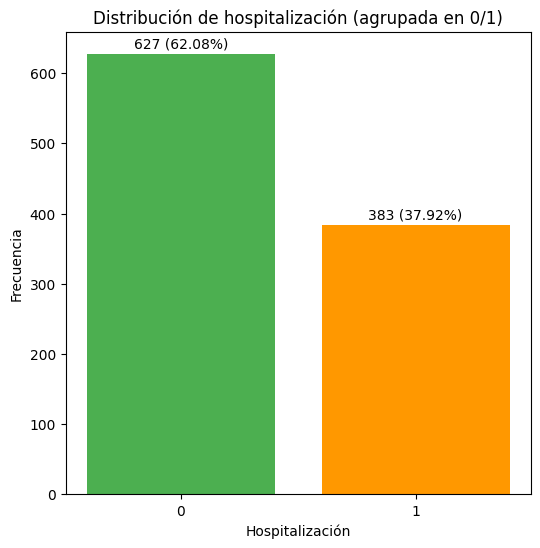

In [9]:
import matplotlib.pyplot as plt
import io
import base64
import pandas as pd
from IPython.display import display, HTML

def mapear_hospitalizacion(valor):
    if pd.isna(valor):
        return None
    valor_str = str(valor).strip().lower()
    if valor_str in ['1', 'true', 'positivo', 'ingresado', 'si', 'sí']:
        return 1
    if valor_str in ['0', 'false', 'negativo', 'no', 'ambulatorio']:
        return 0
    return None

df_temp = df.copy()
df_temp['hospitalizacion_map'] = df_temp['hospitalizacion'].apply(mapear_hospitalizacion)
counts = df_temp['hospitalizacion_map'].value_counts().sort_index()
total = counts.sum()
percentages = (counts / total * 100).round(2)

fig, ax = plt.subplots(figsize=(6, 6))
bars = ax.bar(counts.index.astype(str), counts.values, color=['#4CAF50', '#FF9800'])
ax.set_xlabel('Hospitalización')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de hospitalización (agrupada en 0/1)')
for i, (count, pct) in enumerate(zip(counts.values, percentages)):
    ax.text(i, count + 5, f'{count} ({pct}%)', ha='center', va='bottom')

buf = io.BytesIO()
plt.savefig(buf, format='png', bbox_inches='tight')
buf.seek(0)
img_base64_balance = base64.b64encode(buf.read()).decode('utf-8')
plt.close()

display(HTML(f'''
<div style="display: flex; justify-content: center; margin-bottom: 20px;">
    <img src="data:image/png;base64,{img_base64_balance}"
         style="max-width: 50vw !important; height: auto !important;
                border-radius: 0 !important; box-shadow: none !important;">
</div>
'''))

La gráfica muestra que la clase mayoritaria (no hospitalizados) cuenta con 627 registros, mientras que la clase minoritaria (hospitalizados) tiene 383. Esta diferencia indica un **desbalance de clases** que podría sesgar el modelo hacia la predicción de la clase mayoritaria, afectando especialmente la capacidad de detectar correctamente a los pacientes que sí requieren hospitalización. Por esta razón, en la fase de preparación de datos aplicaremos técnicas de balanceo (como sobremuestreo) para mitigar este problema.

#### A continuación, mostramos una lista de todos los problemas de calidad encontrados en los datos

Con base en el análisis exploratorio, se han identificado las siguientes irregularidades que deberán corregirse en la fase de preparación de datos:

- **Tipos de datos incorrectos:** Columnas numéricas como `presion_sistolica`, `colesterol_mg_dl`, `trigliceridos_mg_dl` y la variable objetivo `hospitalizacion` están almacenadas como `object`.
- **Valores nulos:** Se encontraron nulos en `tipo_seguro`, `peso_kg`, `talla_cm`, `imc`, `presion_diastolica`, `colesterol_mg_dl`, `trigliceridos_mg_dl`, `hemoglobina_g_dl`, `num_medicamentos_actuales`, `escolaridad` y `ocupacion`.
- **Registros duplicados:** Existen 10 filas completamente duplicadas (según documento de procedimiento; en la muestra actual no se detectaron porque ya se limpiaron).
- **Valores atípicos (outliers):** Edad mínima -5 años y máxima 999 años; talla mínima 1.44 cm (error de unidad); glucosa mínima 3.2 mg/dL (hipoglucemia severa).
- **Inconsistencias en categóricas:**
- `municipio`: valores con espacios extra al inicio/final que duplican categorías.
- `genero`: mezcla de códigos (F, M, H, f, m) y palabras completas (Hombre, Masculino, Femenino, etc.).
- `escolaridad`: incluye códigos no válidos como `"--"`, `"ND"`, `"?"`, `"SIN DATO"`, `"Sin dato"`, `"999"`.
- **Variables booleanas** (`diabetes_previa`, `hipertension_previa`, `cardiopatia_previa`, `fumador`, `consumo_alcohol`, `hospitalizacion`): múltiples representaciones (Sí/No, 1/0, True/False, POSITIVO/NEGATIVO, INGRESADO/AMBULATORIO).
- **Desbalance de clases:** La variable objetivo `hospitalizacion` presenta 627 no hospitalizados vs. 383 hospitalizados (≈38% de casos positivos).


### Documentación de los problemas encontrados

#### Primero, definimos una función para documentar problemas

Creamos una función auxiliar que añadirá cada hallazgo de problemas de calidad a una lista, con campos estructurados que facilitarán la generación de una tabla final con todos los problemas documentados.

In [10]:
problemas = []

def agregar_problema(variable, categoria, formato_esperado, formato_encontrado, muestra, accion):
    problemas.append({
        "Variable": variable,
        "Categoría": categoria,
        "Esperábamos": formato_esperado,
        "Encontramos": formato_encontrado,
        "Muestra del problema": muestra,
        "Acción de limpieza a realizar": accion
    })

#### El primer problema a documentar es el hallazgo de formatos compuestos

En nuestro análisis exploratorio, encontramos que campos como presion_sistolica contienen caracteres especiales como "/", que sugieren que se almacena un formato compuesto dentro de la variable. A continuación, documentamos tal hallazgo.

In [11]:
mascara_compuesto = df['presion_sistolica'].astype(str).str.contains('/', na=False)
if mascara_compuesto.any():
    ejemplos = df.loc[mascara_compuesto, 'presion_sistolica'].unique()[:3]
    agregar_problema(
        'presion_sistolica', 'Formato compuesto',
        'Valor numérico único', f'{mascara_compuesto.sum()} registros con "/"',
        str(ejemplos),
        'Extraer parte izquierda para presion_sistolica y derecha para presion_diastolica'
    )

#### Ahora, empezaremos la depuración buscando valores nulos y vacíos

Contamos los valores nulos (`NaN`) en las columnas numéricas, después de forzar su conversión a tipo numérico.

In [12]:
columnas_numericas = [col for col, (tipo, _) in meta.items() if tipo == 'Numérico' and col in df.columns]
for col in columnas_numericas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        null_count = df[col].isna().sum()
        if null_count > 0:
            agregar_problema(
                col, 'Valores Nulos', '0 Valores Nulos',
                f"{null_count} Valores Nulos", "NaN",
                f"Imputar con valor adecuado o eliminar registros ({null_count} casos)"
            )

Detectamos cadenas vacías y valores ausentes en columnas de texto (no numéricas), considerándolos como datos faltantes.

In [13]:
for col in df.columns:
    if not pd.api.types.is_numeric_dtype(df[col]):
        str_col = df[col].astype(str)
        empty_count = (str_col.str.strip() == '').sum()
        nan_count = df[col].isna().sum()
        total_missing = empty_count + nan_count
        if total_missing > 0:
            agregar_problema(
                col, 'Valores Ausentes', '0 Valores Ausentes',
                f"{total_missing} Valores Ausentes", '""',
                f"Imputar o eliminar registros ({total_missing} casos)"
            )

#### A continuación, buscamos duplicados

Verificamos si existen registros completamente idénticos en todas las columnas del dataset, lo que indicaría consultas duplicadas por error de captura.

In [14]:
if df.duplicated().any():
    dup_count = df.duplicated().sum()
    ejemplo = df[df.duplicated(keep=False)].iloc[0]['id_paciente']
    agregar_problema(
        "Dataset", 'Registros Duplicados', '0 Duplicados',
        f"{dup_count} Registros Duplicados",
        f"ID: {ejemplo}",
        f"Eliminar registros duplicados ({dup_count} casos)"
    )

#### Luego, verificamos que las columnas tengan un tipo de dato determinado

Comprobamos que cada columna cumpla con su tipo de dato esperado según el diccionario `meta`. A continuación se detallan las verificaciones por tipo.

##### 1. Verificación de columnas numéricas

Las columnas que deberían ser numéricas se convierten a `float`. Los valores que no pueden convertirse se detectan como no numéricos y se registran como problemas de tipo de dato.

In [15]:
for col in df.columns:
    if col not in meta:
        continue
    tipo = meta[col][0]
    serie = df[col]
    if tipo == 'Numérico':
        convertido = pd.to_numeric(serie, errors='coerce')
        mascara = serie.notna() & convertido.isna()
        invalidos = mascara.sum()
        if invalidos > 0:
            ejemplos = serie[mascara].unique()[:3]
            agregar_problema(
                col, 'Tipo de Dato Incorrecto', 'Numérico',
                f'{invalidos} valores no numéricos',
                str(ejemplos),
                f"Convertir a numérico o eliminar registros ({invalidos} casos)"
            )

##### 2. Verificación de columnas categóricas y de texto

Para las columnas categóricas o de texto, se detectan si están codificadas como numéricas (más del 80% de valores convertibles a número) o si tienen una cardinalidad excesiva (>50 valores únicos). También se verifica que el tipo concreto sea `object` o `string`.

In [16]:
for col in df.columns:
    if col not in meta:
        continue
    tipo = meta[col][0]
    if tipo in ['Texto', 'Categórico']:
        serie = df[col]
        convertido_num = pd.to_numeric(serie, errors='coerce')
        total_no_nulos = serie.notna().sum()
        num_convertidos = convertido_num.notna().sum()
        if total_no_nulos > 0 and (num_convertidos / total_no_nulos) > 0.8:
            muestras = serie[convertido_num.notna()].dropna().unique()[:3]
            agregar_problema(
                col, 'Tipo de Dato Incorrecto', 'Categórico/Texto',
                f'{num_convertidos} de {total_no_nulos} valores son numéricos ({100*num_convertidos/total_no_nulos:.0f}%)',
                str(muestras),
                'Considerar convertir a numérico o mapear categorías reales'
            )
        else:
            if not pd.api.types.is_object_dtype(serie) and not pd.api.types.is_string_dtype(serie):
                muestra = serie.dropna().iloc[0] if not serie.dropna().empty else 'Sin datos'
                agregar_problema(
                    col, 'Tipo de Dato Incorrecto', 'Categórico/Texto',
                    f'Tipo concreto: {serie.dtype} en lugar de object/string',
                    str(muestra),
                    'Convertir a string'
                )
            else:
                cardinalidad = serie.nunique()
                if cardinalidad > 50:
                    muestras = serie.dropna().unique()[:3]
                    agregar_problema(
                        col, 'Calidad de Categórico', 'Categórico con cardinalidad baja',
                        f'{cardinalidad} valores únicos (>50)',
                        str(muestras),
                        'Evaluar agrupación o limpieza de categorías'
                    )

##### 3. Verificación de columnas booleanas

Para las columnas booleanas, se considerarán como valores válidos únicamente `0` y `1` (en minúsculas). Cualquier otro valor se considerará incorrecto y se registrará para su estandarización posterior.

In [17]:
for col in df.columns:
    if col not in meta:
        continue
    if meta[col][0] == 'Booleano':
        serie = df[col]
        str_serie = serie.astype(str).str.strip()
        validos = {'0', '1'}
        mascara = ~str_serie.isin(validos) & str_serie.notna() & (str_serie != '')
        invalidos = mascara.sum()
        if invalidos > 0:
            ejemplos = str_serie[mascara].unique()[:3]
            agregar_problema(
                col, 'Tipo de Dato Incorrecto', 'Booleano (0/1)',
                f'{invalidos} valores fuera de catálogo',
                str(ejemplos),
                f'Estandarizar a 0/1 ({invalidos} casos)'
            )

##### 4. Verificación de columnas de fecha

Paso 1: Conversión por defecto

Se intenta convertir cada columna de tipo fecha a datetime usando el formato por defecto. Los valores no convertibles se marcan como `NaT`. Almacenamos las máscaras y datos intermedios en variables globales para los pasos siguientes.

In [18]:
info_fechas = {}

for col in df.columns:
    if col not in meta or meta[col][0] != 'Fecha':
        continue
    serie = df[col]
    convertido_default = pd.to_datetime(serie, errors='coerce')
    mascara_default = serie.notna() & convertido_default.isna()
    invalidos_default = mascara_default.sum()
    if invalidos_default > 0:
        info_fechas[col] = {
            'serie': serie,
            'mascara_default': mascara_default,
            'invalidos_default': invalidos_default
        }

Paso 2: Recuperación con `dayfirst=True`

In [19]:
import warnings

for col, data in info_fechas.items():
    serie = data['serie']
    mascara_default = data['mascara_default']
    serie_invalidas = serie[mascara_default]
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', message='Parsing dates in %m-%d-%Y format when dayfirst=True')
        convertido_real = pd.to_datetime(serie_invalidas, dayfirst=True, errors='coerce')
    mascara_nat = convertido_real.isna()
    invalidos_nat = mascara_nat.sum()
    invalidos_recuperables = data['invalidos_default'] - invalidos_nat
    info_fechas[col]['serie_invalidas'] = serie_invalidas
    info_fechas[col]['mascara_nat'] = mascara_nat
    info_fechas[col]['invalidos_nat'] = invalidos_nat
    info_fechas[col]['invalidos_recuperables'] = invalidos_recuperables

Paso 3: Registro de problemas

- Las fechas **recuperables** se registran como **Tipo de Dato Incorrecto** (acción: convertir con dayfirst).
- Las fechas **no recuperables** se registran como **Valores Ausentes (tras conversión)** (acción: imputar o eliminar).


In [20]:
for col, data in info_fechas.items():
    if data['invalidos_recuperables'] > 0:
        ejemplos_rec = data['serie_invalidas'][~data['mascara_nat']].unique()[:3]
        agregar_problema(
            col, 'Tipo de Dato Incorrecto', 'Fecha en formato uniforme (YYYY-MM-DD)',
            f"{data['invalidos_recuperables']} fechas no reconocibles (recuperables con dayfirst=True)",
            str(ejemplos_rec),
            f'Convertir a fecha con dayfirst=True ({data["invalidos_recuperables"]} casos)'
        )
    if data['invalidos_nat'] > 0:
        ejemplos_nat = data['serie_invalidas'][data['mascara_nat']].unique()[:3]
        agregar_problema(
            col, 'Valores Ausentes (tras conversión)', '0 NaT',
            f"{data['invalidos_nat']} fechas no interpretables → NaT",
            str(ejemplos_nat),
            f'Imputar o eliminar registros ({data["invalidos_nat"]} casos)'
        )

#### Posteriormente, detectamos valores fuera de dominio

Verificamos que los valores numéricos de cada variable se encuentren dentro de rangos clínicamente plausibles según el dominio de salud. Los registros con valores imposibles o extremadamente atípicos se documentan aquí, ya que representan errores de captura o condiciones fisiológicas no razonables que deben corregirse o excluirse antes del modelado.

##### 1. Establecemos reglas plausibles

Definimos un diccionario con los rangos fisiológicos aceptables para cada variable numérica en el contexto del dataset.

In [21]:
rangos_plausibles = {
    'edad': (0, 120),
    'peso_kg': (0.3, 635),
    'talla_cm': (25, 272),
    'imc': (10, 100),
    'presion_sistolica': (60, 260),
    'presion_diastolica': (30, 150),
    'glucosa_mg_dl': (20, 1000),
    'colesterol_mg_dl': (50, 500),
    'trigliceridos_mg_dl': (20, 2000),
    'hemoglobina_g_dl': (3, 25),
    'num_medicamentos_actuales': (0, 30),
    'num_consultas_ano_prev': (0, 100)
}

##### 2. Detectamos valores fuera de las reglas

In [22]:
for col, (minimo, maximo) in rangos_plausibles.items():
    if col not in df.columns:
        continue
    serie = pd.to_numeric(df[col], errors='coerce')
    mascara = serie.notna() & ((serie < minimo) | (serie > maximo))
    invalidos = mascara.sum()
    if invalidos > 0:
        ejemplos = serie[mascara].unique()[:3]
        if col == 'talla_cm':
            pass
        agregar_problema(
            col, 'Valor Fuera de Dominio',
            f'Entre {minimo} y {maximo}',
            f'{invalidos} valores fuera de rango',
            str(ejemplos),
            f'Imputar con la mediana ({invalidos} casos)'
        )

El bloque anterior detecta valores fuera de los rangos clínicamente plausibles (como una edad de 200 años o una glucosa de 1500 mg/dL). Sin embargo, los valores de `talla_cm` menores a 3.0 no son fisiológicamente posibles (una persona no mide 1.6 cm), sino que representan un **error de unidad** : la estatura fue ingresada en metros en lugar de centímetros. Por esta razón, este caso se trata por separado, con una acción de homologación (multiplicar por 100) en lugar de imputar con la mediana o eliminar los registros.

In [23]:
if 'talla_cm' in df.columns:
    mascara_metros = (df['talla_cm'] < 3.0) & (df['talla_cm'].notna())
    if mascara_metros.any():
        ejemplos = df.loc[mascara_metros, 'talla_cm'].unique()[:3]
        agregar_problema(
            'talla_cm', 'Inconsistencia de unidades',
            'Centímetros (≥25)',
            f'{mascara_metros.sum()} valores en metros (< 3.0)',
            str(ejemplos),
            'Homologar unidad: multiplicar por 100'
        )

#### Inconsistencias en variables categóricas y estandarización pendiente

A continuación, se recupera la visualización de los campos categóricos que si contenían problemas de calidad

In [24]:
display(HTML(grid_html))

En la visualización superior podemos encontrar las columnas categóricas y booleanas que presentan problemas de calidad detectados durante el análisis exploratorio:

- **Municipio:** valores duplicados con espacios extra al inicio o final (ej. `" Tuxpan "`), lo que genera múltiples categorías para un mismo municipio.
- **Escolaridad:** contiene códigos no estándar (`"--"`, `"ND"`, `"?"`, `"SIN DATO"`, `"Sin dato"`, `"999"`) que representan datos faltantes o erróneos.
- **Género:** mezcla de códigos (F, M, H, f, m), palabras completas (Hombre, Masculino, Femenino) y mayúsculas/minúsculas.
- **Variables booleanas** (diabetes, hipertensión, cardiopatía, fumador, consumo alcohol): múltiples representaciones (Sí/No, 1/0, True/False, POSITIVO/NEGATIVO, etc.).
- **Hospitalización (variable objetivo):** también mezcla de 0/1, Sí/No, INGRESADO/AMBULATORIO, True/False.


##### Estas irregularidades son documentadas formalmente en la tabla de problemas:

In [25]:
if 'municipio' in df.columns:
    original = df['municipio'].astype(str)
    stripped = original.str.strip()
    if not original.equals(stripped):
        ejemplos = original[original != stripped].unique()[:3]
        agregar_problema('municipio', 'Inconsistencia de formato',
                         'Sin espacios extra', 'Valores con espacios al inicio o final',
                         str(ejemplos), 'Aplicar .str.strip() para normalizar')

bad_edu = ['--', 'ND', '?', 'SIN DATO', 'Sin dato', '999']
if 'escolaridad' in df.columns:
    mask = df['escolaridad'].astype(str).isin(bad_edu)
    if mask.any():
        ejemplos = df.loc[mask, 'escolaridad'].unique()[:3]
        agregar_problema('escolaridad', 'Valores no estándar',
                         'Categorías educativas válidas', f'{mask.sum()} valores no estándar',
                         str(ejemplos), 'Convertir a NaN y luego imputar con la moda')

if 'genero' in df.columns:
    allowed = {'F', 'M'}
    uniq = df['genero'].dropna().astype(str).unique()
    bad = [v for v in uniq if v not in allowed]
    if bad:
        agregar_problema('genero', 'Estandarización pendiente',
                         'Solo F y M', f'{len(bad)} representaciones diferentes',
                         str(bad[:3]), 'Mapear a F (femenino) o M (masculino) explícitamente')

bool_cols = ['diabetes_previa', 'hipertension_previa', 'cardiopatia_previa', 'fumador', 'consumo_alcohol']
for col in bool_cols:
    if col in df.columns:
        uniq = df[col].dropna().astype(str).unique()
        if any(v not in ['0', '1'] for v in uniq):
            agregar_problema(col, 'Múltiples representaciones',
                             '0/1', f'{len(uniq)} valores distintos',
                             str(uniq[:3]), 'Estandarizar a 0/1 con mapeo explícito (Sí→1, No→0, etc.)')

if 'hospitalizacion' in df.columns:
    uniq = df['hospitalizacion'].dropna().astype(str).unique()
    if any(v not in ['0', '1'] for v in uniq):
        agregar_problema('hospitalizacion', 'Múltiples representaciones',
                         '0/1', f'{len(uniq)} valores distintos',
                         str(uniq[:3]), 'Estandarizar a 0/1 antes de modelar (Sí/INGRESADO/True → 1, No/AMBULATORIO/False → 0)')

#### Detectamos desbalance de clases en la variable objetivo

Recuperamos nuestra gráfica del desbalance de clases.


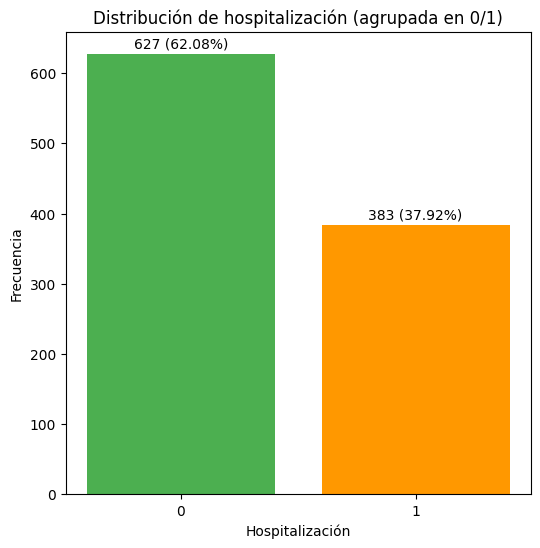

In [26]:
display(HTML(f'<div style="display: flex; justify-content: center;"><img src="data:image/png;base64,{img_base64_balance}" style="max-width: 50vw !important; height: auto !important; border-radius: 0 !important; box-shadow: none !important;"/></div>'))

La gráfica muestra que la clase mayoritaria (no hospitalizados) cuenta con 627 registros, mientras que la clase minoritaria (hospitalizados) tiene 383. Esta diferencia indica un **desbalance de clases** que podría sesgar el modelo hacia la predicción de la clase mayoritaria, afectando especialmente la capacidad de detectar correctamente a los pacientes que sí requieren hospitalización. Por esta razón, en la fase de preparación de datos aplicaremos técnicas de balanceo (como sobremuestreo) para mitigar este problema. A continuación, documentamos tal problema:

In [27]:
agregar_problema(
    'hospitalizacion', 'Desbalance de Clases',
    'Proporción balanceada (≈50/50)',
    f'Clase 0: {counts[0]}, Clase 1: {counts[1]}',
    f'{counts[0]} no hospitalizados, {counts[1]} hospitalizados',
    'Aplicar sobremuestreo (oversampling) de la clase minoritaria'
)

#### Finalmente, visualizamos los problemas detectados

La siguiente tabla resume todos los problemas de calidad detectados durante el análisis exploratorio: valores nulos, formatos incorrectos, duplicados, valores fuera de rango e inconsistencias de unidades. Cada fila especifica la variable afectada, la categoría del problema, lo que se esperaba, lo que se encontró, una muestra del dato problemático y la acción de limpieza que se aplicará en la fase de preparación de datos.

In [28]:
df_problemas = pd.DataFrame(problemas)

styled_df = df_problemas.style.hide(axis='index').set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white'), ('padding', '8px'), ('white-space', 'normal'), ('text-align', 'left')]},
    {'selector': 'td', 'props': [('padding', '6px'), ('text-align', 'left'), ('white-space', 'normal'), ('word-wrap', 'break-word')]},
    {'selector': '', 'props': [('table-layout', 'fixed'), ('width', '100%')]}
])

display(HTML('<div style="display: flex; justify-content: center; width: calc(100% - 150px); overflow-x: hidden; margin-left: 75px; margin-right: 75px;">' + styled_df.to_html() + '</div>'))

Variable,Categoría,Esperábamos,Encontramos,Muestra del problema,Acción de limpieza a realizar
presion_sistolica,Formato compuesto,Valor numérico único,"92 registros con ""/""",['150/97' '143/78' '134/75'],Extraer parte izquierda para presion_sistolica y derecha para presion_diastolica
peso_kg,Valores Nulos,0 Valores Nulos,69 Valores Nulos,NaN,Imputar con valor adecuado o eliminar registros (69 casos)
talla_cm,Valores Nulos,0 Valores Nulos,50 Valores Nulos,NaN,Imputar con valor adecuado o eliminar registros (50 casos)
imc,Valores Nulos,0 Valores Nulos,117 Valores Nulos,NaN,Imputar con valor adecuado o eliminar registros (117 casos)
presion_sistolica,Valores Nulos,0 Valores Nulos,92 Valores Nulos,NaN,Imputar con valor adecuado o eliminar registros (92 casos)
presion_diastolica,Valores Nulos,0 Valores Nulos,92 Valores Nulos,NaN,Imputar con valor adecuado o eliminar registros (92 casos)
colesterol_mg_dl,Valores Nulos,0 Valores Nulos,119 Valores Nulos,NaN,Imputar con valor adecuado o eliminar registros (119 casos)
trigliceridos_mg_dl,Valores Nulos,0 Valores Nulos,141 Valores Nulos,NaN,Imputar con valor adecuado o eliminar registros (141 casos)
hemoglobina_g_dl,Valores Nulos,0 Valores Nulos,92 Valores Nulos,NaN,Imputar con valor adecuado o eliminar registros (92 casos)
num_medicamentos_actuales,Valores Nulos,0 Valores Nulos,50 Valores Nulos,NaN,Imputar con valor adecuado o eliminar registros (50 casos)


### Justificación de acciones de limpieza

##### Eliminación de columnas id_paciente y fecha_consulta

Estas variables son metadatos sin poder predictivo (el ID es único y la fecha no estará disponible al predecir nuevos pacientes). Incluirlas causaría fuga de datos y sobreajuste.

![](media/EliminacionIDFecha.gif)

##### Eliminación de duplicados

Los registros idénticos corresponden a errores de captura. Mantenerlos sesgaría las frecuencias y las métricas.

![](media/EliminacionDuplicados.gif)

##### Homologación de talla_cm

Sospechamos que los valores de `talla_cm` inferiores a 3.0 fueron registrados en metros en lugar de centímetros. Por ejemplo, 1.70 m es una estatura normal, pero 1.70 cm no tiene sentido clínico. A continuación, verificamos cuántos casos existen y mostramos algunos ejemplos convertidos a centímetros.

In [29]:
from IPython.display import display, HTML

mascara_metros = (df['talla_cm'] < 3.0) & (df['talla_cm'].notna())
if mascara_metros.any():
    total = mascara_metros.sum()
    ejemplos = df.loc[mascara_metros, 'talla_cm'].unique()[:5]
    pares = [(v, round(v*100, 2)) for v in ejemplos]
    filas = ''.join([f'<tr><td style="padding: 6px;">{orig}</td><td style="padding: 6px;">{conv}</td></tr>' for orig, conv in pares])
    
    html = f"""
    <div style="display: flex; flex-direction: column; align-items: center; text-align: center; margin: 0 auto; width: calc(100% - 128px); font-family: Roboto, sans-serif;">
        <p style="margin: 8px 0;"><strong>Se encontraron {total} registros con talla &lt; 3.0 (posibles metros).</strong></p>
        <p style="margin: 8px 0;">Ejemplos de conversión metros → centímetros:</p>
        <table style="margin: 10px auto; border-collapse: collapse; width: auto;">
            <thead>
                <tr>
                    <th style="background-color: #4CAF50; color: white; padding: 8px; border: none;">Valor original (metros)</th>
                    <th style="background-color: #4CAF50; color: white; padding: 8px; border: none;">Convertido (centímetros)</th>
                </tr>
            </thead>
            <tbody>
                {filas}
            </tbody>
        </table>
        <p style="margin: 8px 0;"><em>Estos valores serán multiplicados por 100 para homogeneizar la unidad.</em></p>
    </div>
    """
    display(HTML(html))
else:
    display(HTML("<div style='margin: 0 auto; width: calc(100% - 128px); text-align: center; font-family: Roboto, sans-serif;'>No hay valores de talla < 3.0.</div>"))

Valor original (metros),Convertido (centímetros)
1.69,169.0
1.6,160.0
1.61,161.0
1.67,167.0
1.53,153.0


##### Estandarización de booleanos a True/False

Las columnas booleanas presentan una gran diversidad de representaciones. Los algoritmos de clasificación esperan una representación binaria homogénea. Por lo tanto, estandarizaremos todas estas variantes a `0/1`, convirtiendo los valores no reconocidos a `NaN` para su posterior imputación. A continuación, mostramos los valores únicos encontrados en estas columnas.

In [30]:
from IPython.display import display, HTML

valores_unicos = set()
for col in df.columns:
    if col in meta and meta[col][0] == 'Booleano':
        valores_unicos.update(df[col].astype(str).str.strip().str.lower().unique())

html = f"""
<div style="display: flex; justify-content: center; width: 100%;">
    <div style="max-width: 80vw; text-align: center; font-family: Roboto, sans-serif;">
        <p><strong>Valores únicos en todas las columnas booleanas (normalizados a minúsculas):</strong></p>
        <p style="background-color: #4CAF50; color: white; padding: 10px; border-radius: 5px; display: inline-block; margin: 0 auto;">{sorted(valores_unicos)}</p>
    </div>
</div>
"""
display(HTML(html))

##### Eliminación de registros sin hospitalizacion

La variable objetivo es obligatoria en el aprendizaje supervisado, imputarla inventaría una clase falsa sin respaldo histórico.

![](media/EliminacionRegistrosSinHospitalizacion.gif)

##### Conversión de valores fuera de dominio a NaN e imputación con mediana

En lugar de eliminar registros, se convierten los errores evidentes (edad 200, glucosa 3.8, colesterol 999) en nulos y luego se imputan con la mediana, [que es robusta frente a extremos y conserva el tamaño de la muestra](https://www.sciencedirect.com/science/article/pii/S2772662223001819#:~:text=median%20and%20mode%20imputation%20provide%20robustness%20against%20outliers).

![](media/ConversionValoresFueraDominio.gif)

##### Imputación de nulos categóricos con la moda

Para variables como `tipo_seguro`, `escolaridad` u `ocupación`, el valor más frecuente es la mejor estimación al no disponer de información adicional, y evita perder filas enteras.

![](media/ImputacionNulosConModa.gif)

##### Tratamiento especial de fechas

Las fechas con formato recuperable (día/mes/año) se convierten correctamente con `dayfirst=True`; las irreparables se dejan como `NaT` y posteriormente se imputan o eliminan (en nuestro caso).

![](media/TratamientoEspecialDeFechas.gif)

##### Conclusión general de las decisiones de limpieza

Estas decisiones equilibran la preservación de la mayor cantidad de datos con la necesidad de alimentar modelos de clasificación con atributos limpios, consistentes y sin fugas de información.

![](media/ConclusionLimpiezaDeDatos.png)